In [100]:
import pandas as pd
import seaborn as sns
import sklearn
import numpy as np
from pandas.io.formats.style import Styler
import matplotlib.pyplot as plt

To install a package: ./.venv/bin/python -m pip install package-name

This is the copied [ML in Neuroscience workshop notebook](https://zvibaratz.github.io/ml_for_neuro/chapters/chapter_03/exercise_03.html) with own comments. The exercise itself was based on [sklearn tutorial](https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols_ridge.html) on Ordinary Least Squares (and Ridge Regression, see ols_ridge_sklearn.ipynb).

## Loading the dataset

In [101]:
from sklearn import datasets
dataset = datasets.load_diabetes(as_frame = True)

In [102]:
X, y = dataset.data, dataset.target
data = pd.concat([X, y], axis = 1)

## Basic exploration

### dataset description

In [103]:
print(dataset.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### raw inspection

In [104]:
#num spefifies how many samples to generate within the [start, stop] interval

sample_indices = np.linspace(0, len(X) - 4, 4, dtype = int) #endpoint=True default (including)
sample_indices = [ind for i in sample_indices for ind in range(i, i + 4)] #for each sample add 3 closest indices
sample_indices

[0, 1, 2, 3, 146, 147, 148, 149, 292, 293, 294, 295, 438, 439, 440, 441]

In [105]:
subdata = data.iloc[sample_indices, :] #choose only rows of that indices & all columns
subdata

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.0380759,0.0506801,0.0616962,0.0218724,-0.0442235,-0.0348208,-0.0434008,-0.00259226,0.0199075,-0.0176461,151
1,-0.00188202,-0.0446416,-0.0514741,-0.0263275,-0.00844872,-0.0191633,0.0744116,-0.0394934,-0.0683315,-0.092204,75
2,0.0852989,0.0506801,0.0444512,-0.00567042,-0.0455995,-0.0341945,-0.0323559,-0.00259226,0.00286131,-0.0259303,141
3,-0.0890629,-0.0446416,-0.011595,-0.0366561,0.0121906,0.0249906,-0.0360376,0.0343089,0.0226877,-0.00936191,206
146,-0.0309423,0.0506801,0.0595406,0.00121528,0.0121906,0.0315667,-0.0434008,0.0343089,0.014821,0.00720652,178
147,-0.0563701,-0.0446416,0.0929528,-0.0194418,0.0149425,0.0234249,-0.0286743,0.0254526,0.0260605,0.0403434,128
148,-0.0600026,0.0506801,0.0153503,-0.0194418,0.0369577,0.0481636,0.019187,-0.00259226,-0.0307479,-0.0010777,96
149,-0.049105,0.0506801,-0.00512814,-0.0469846,-0.0208323,-0.0204159,-0.0691723,0.07121,0.0612376,-0.0383567,126
292,0.0090156,-0.0446416,-0.0223731,-0.0320771,-0.0497273,-0.0686408,0.0780932,-0.0708593,-0.0629169,-0.0383567,84
293,-0.0709002,-0.0446416,0.0929528,0.01268,0.0204463,0.0425269,0.000778808,0.000359828,-0.0545396,-0.0010777,200


Fatures are normalized [-1,1]

In [106]:
styled = (
    subdata.style
    .set_properties(**{"text-align": "center"})
    .set_properties(
        **{"border-left": "5px solid red"},
        subset=["target"], #seperete the target column visually
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [("font-size", "13px")],
        },
        {
            "selector": "td",
            "props": [("font-size", "11px")],
        },
    ])
    .background_gradient()
    .format(precision=3)
)

styled

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038,0.051,0.062,0.022,-0.044,-0.035,-0.043,-0.003,0.020,-0.018,151.000
1,-0.002,-0.045,-0.051,-0.026,-0.008,-0.019,0.074,-0.039,-0.068,-0.092,75.000
2,0.085,0.051,0.044,-0.006,-0.046,-0.034,-0.032,-0.003,0.003,-0.026,141.000
3,-0.089,-0.045,-0.012,-0.037,0.012,0.025,-0.036,0.034,0.023,-0.009,206.000
146,-0.031,0.051,0.060,0.001,0.012,0.032,-0.043,0.034,0.015,0.007,178.000
147,-0.056,-0.045,0.093,-0.019,0.015,0.023,-0.029,0.025,0.026,0.040,128.000
148,-0.060,0.051,0.015,-0.019,0.037,0.048,0.019,-0.003,-0.031,-0.001,96.000
149,-0.049,0.051,-0.005,-0.047,-0.021,-0.020,-0.069,0.071,0.061,-0.038,126.000
292,0.009,-0.045,-0.022,-0.032,-0.050,-0.069,0.078,-0.071,-0.063,-0.038,84.000
293,-0.071,-0.045,0.093,0.013,0.020,0.043,0.001,0.000,-0.055,-0.001,200.000


In [107]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


### descriptive statistics

In [108]:
pd.set_option('float_format', '{:g}'.format)
data.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442,442,442,442,442,442,442,442,442,442,442
mean,-2.51182e-19,1.23079e-17,-2.24556e-16,-4.79757e-17,-1.3815e-17,3.91843e-17,-5.77718e-18,-9.04254e-18,9.2686e-17,1.13032e-17,152.133
std,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,77.093
min,-0.107226,-0.0446416,-0.0902753,-0.112399,-0.126781,-0.115613,-0.102307,-0.0763945,-0.126097,-0.137767,25
25%,-0.0372993,-0.0446416,-0.0342291,-0.0366561,-0.0342478,-0.0303584,-0.0351172,-0.0394934,-0.0332456,-0.033179,87
50%,0.00538306,-0.0446416,-0.00728377,-0.00567042,-0.00432087,-0.00381907,-0.00658447,-0.00259226,-0.00194717,-0.0010777,140.5
75%,0.0380759,0.0506801,0.031248,0.0356438,0.028358,0.0298444,0.0293115,0.0343089,0.0324323,0.0279171,211.5
max,0.110727,0.0506801,0.170555,0.132044,0.153914,0.198788,0.181179,0.185234,0.133597,0.135612,346


### scatter matrix

In [109]:
numeric_data = data.drop(["sex"], axis = 1)

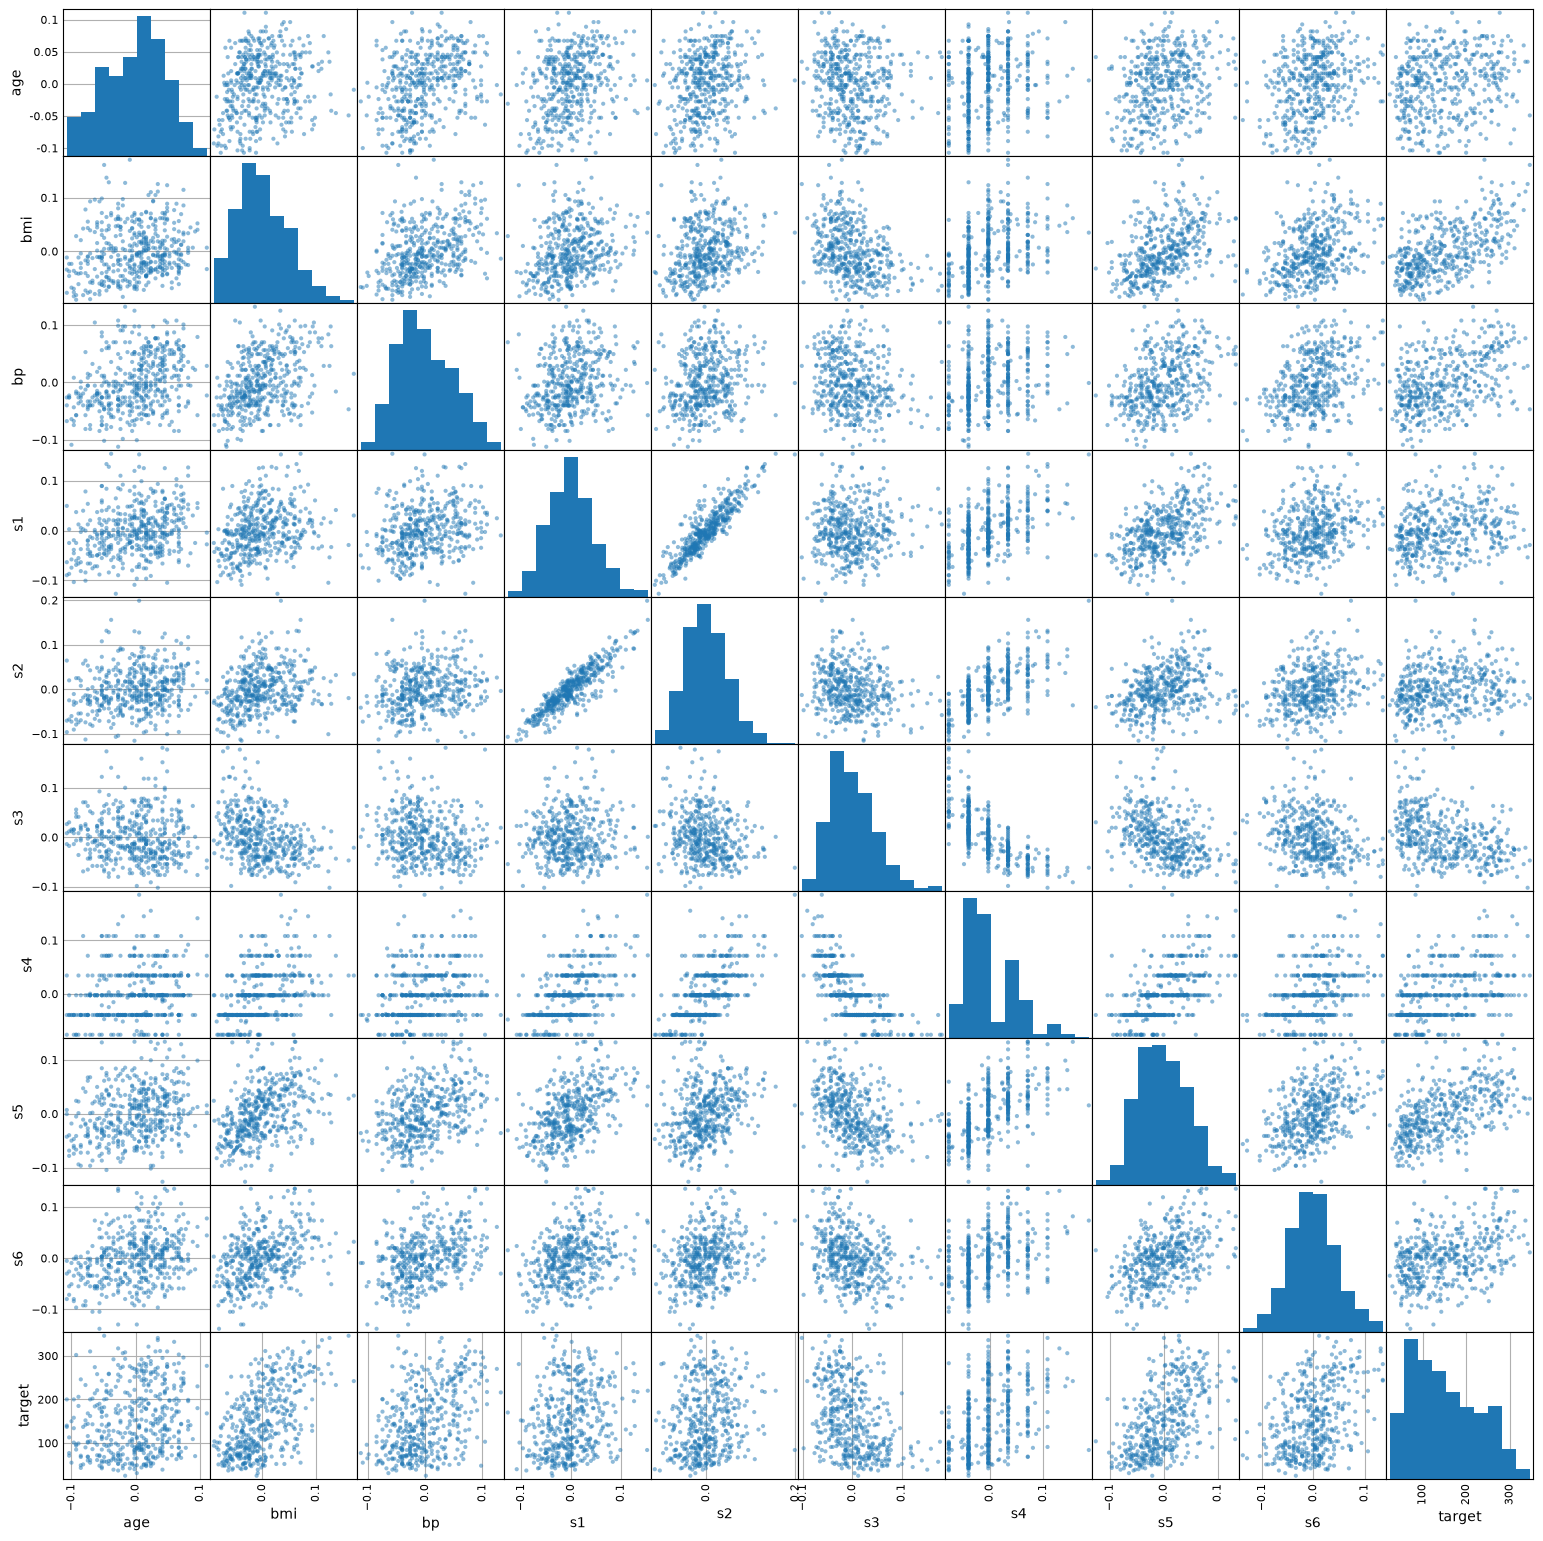

In [110]:
axes = pd.plotting.scatter_matrix(numeric_data, figsize = (15,15))
fixed_labels = [round(float(i.get_text()),2) for i in axes[0,0].get_yticklabels()]
_ = axes[0,0].set_yticklabels(fixed_labels)

### feature correlation

In [111]:
correlation_matrix = np.corrcoef(data.values.T)
#transposiotion, because numpy correlation function treats rows as features and columns as observations 

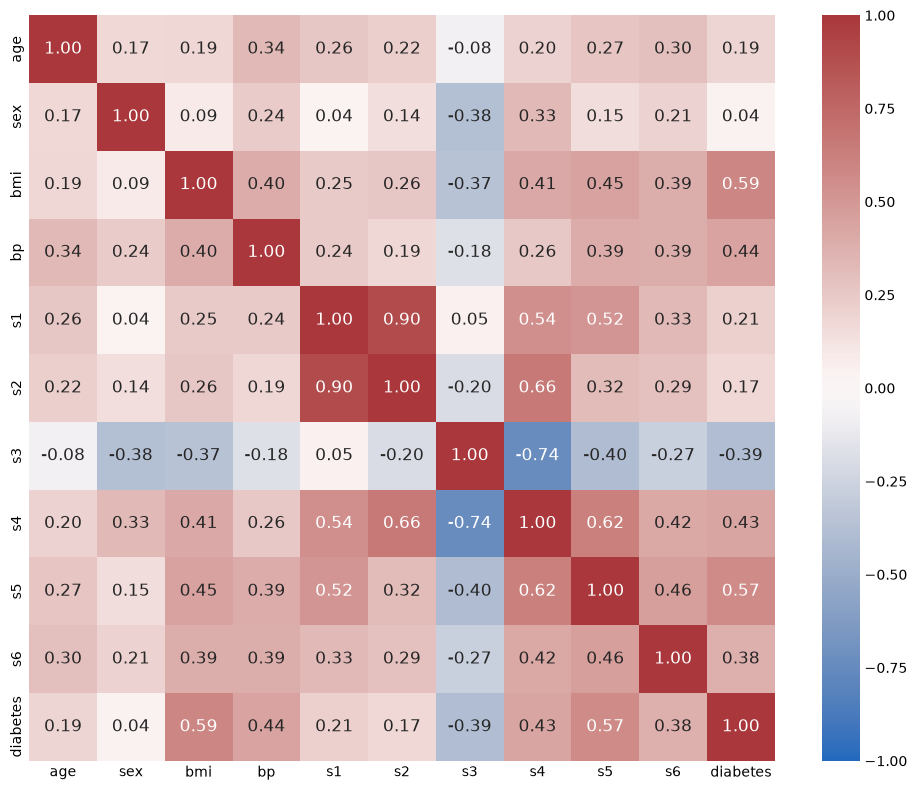

In [112]:
fig, ax = plt.subplots(figsize = (10, 8))
tick_labels = list(X.columns) + ['diabetes']

HM = sns.heatmap(data = correlation_matrix, 
                 ax = ax,
                 cbar = True, #show colorbar
                 cmap = 'vlag', #specify colormap
                 vmin = -1,
                 vmax = +1, #due to features standarization
                 annot = True, #show the value of each cell
                 square = True, #cell sizing 
                 fmt = '.2f', #float formatting
                 annot_kws = {'size': 12}, #font size of values displayed within the cells
                 xticklabels = tick_labels,
                 yticklabels = tick_labels,
                 )
plt.tight_layout()
plt.show()

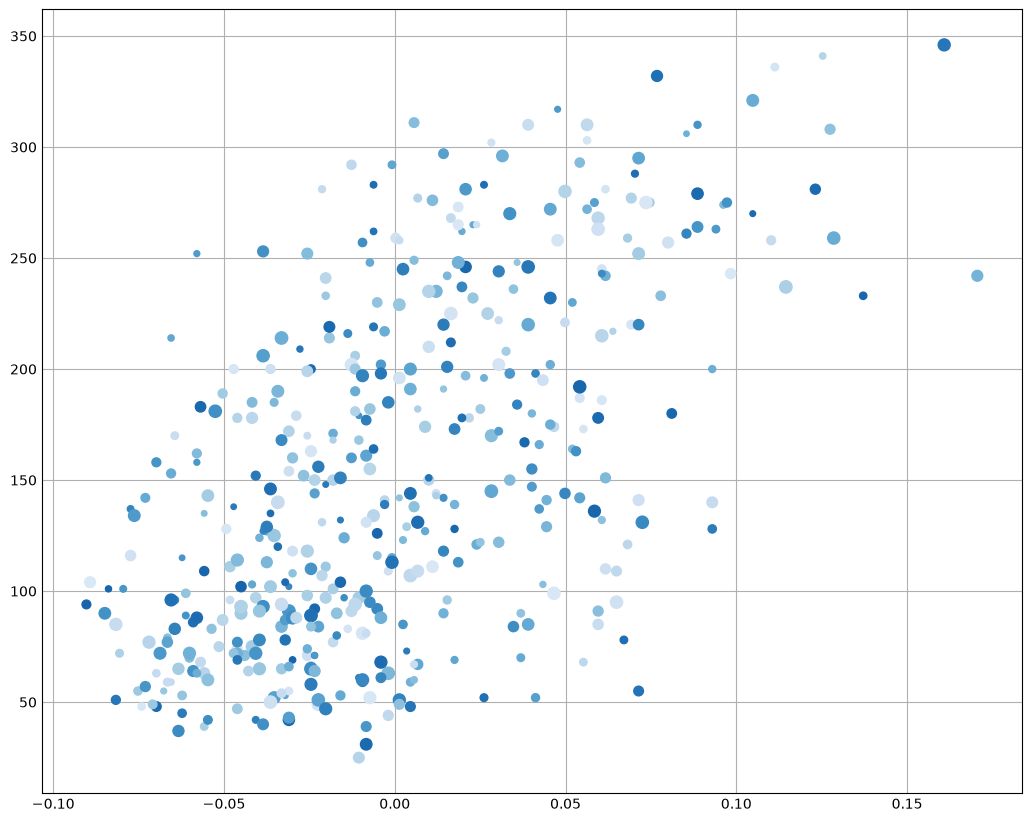

In [113]:
plt.style.use('_mpl-gallery')
sizes = np.random.uniform(15, 80, len(y))
colors = np.random.uniform(15, 80, len(y))

fig, ax = plt.subplots(figsize = (10, 8))
ax.scatter(data['bmi'], y, s=sizes, c=colors, vmin=0, vmax=100)
plt.show()

# Simple Linear Regression (SLR)

Simple linear regression is a linear regression model with a single explanatory variable (feature, X, independent variable). bmi seems to show a discernible linear relationship with the target variable, so let’s go with that one.

https://en.wikipedia.org/wiki/Simple_linear_regression

## train/test split

In [114]:
from sklearn.model_selection import train_test_split

In [115]:
simple_X = X.bmi.to_numpy().reshape(len(X), 1) # vector of. asingle predictor values

In [116]:
simple_X_train, simple_X_test, y_train, y_test = train_test_split(simple_X,
                                                                  y,
                                                                  random_state = 0,
                                                                  test_size = 0.2)

In [117]:
print("Shapes of training set observations:")
simple_X_train.shape, y_train.shape

Shapes of training set observations:


((353, 1), (353,))

In [118]:
print("Shapes of testing set observations:")
simple_X_test.shape, y_test.shape

Shapes of testing set observations:


((89, 1), (89,))

### model creation

In [119]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
_ = model.fit(simple_X_train, y_train)

### model application

In [120]:
simple_y_pred = model.predict(simple_X_test)

### model evaluation

#### plots

Let's plot:
* predicted values alongside the observed (simple_y_pred, y_test)
* regression line estimated by the model

On both training and test data

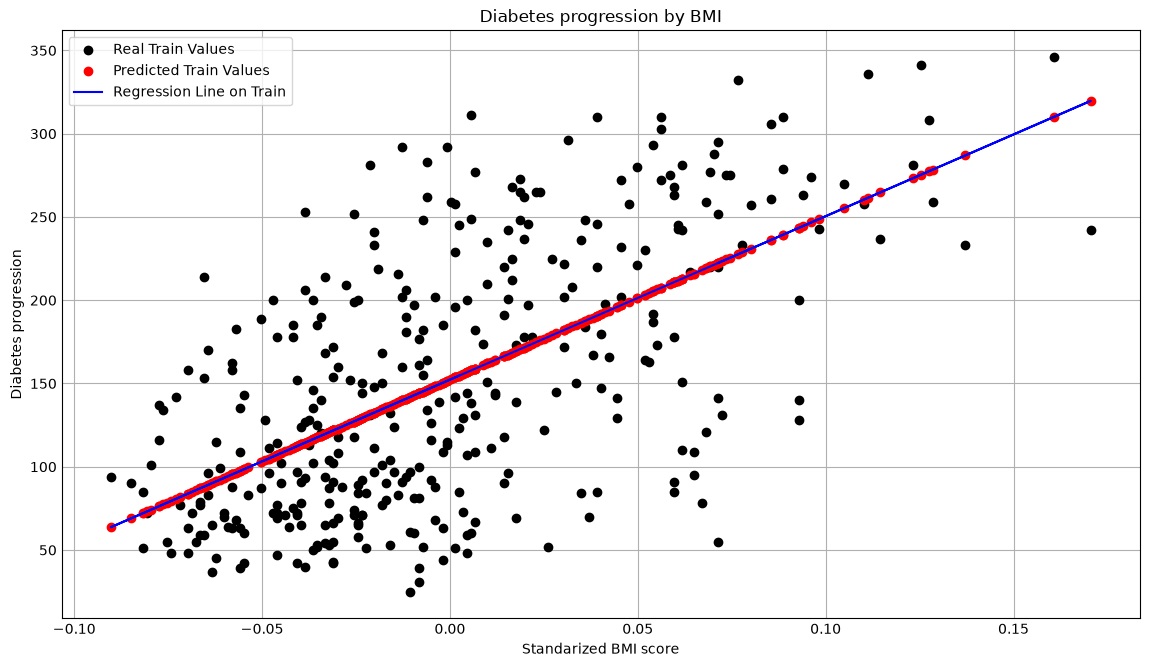

In [168]:
fig, ax = plt.subplots(figsize = (11,6))

_ = plt.scatter(simple_X_train, y_train, 
                color = 'black',
                label = "Real Train Values")

_ = plt.scatter(simple_X_train, model.predict(simple_X_train),
                color = 'red',
                label = 'Predicted Train Values')

_ = plt.plot(simple_X_train, model.predict(simple_X_train),
             color = 'blue',
             label = 'Regression Line on Train')

_ = plt.legend()

title = "Diabetes progression by BMI"
plt.title(title)

_ = ax.set_xlabel("Standarized BMI score")
_ = ax.set_ylabel("Diabetes progression")

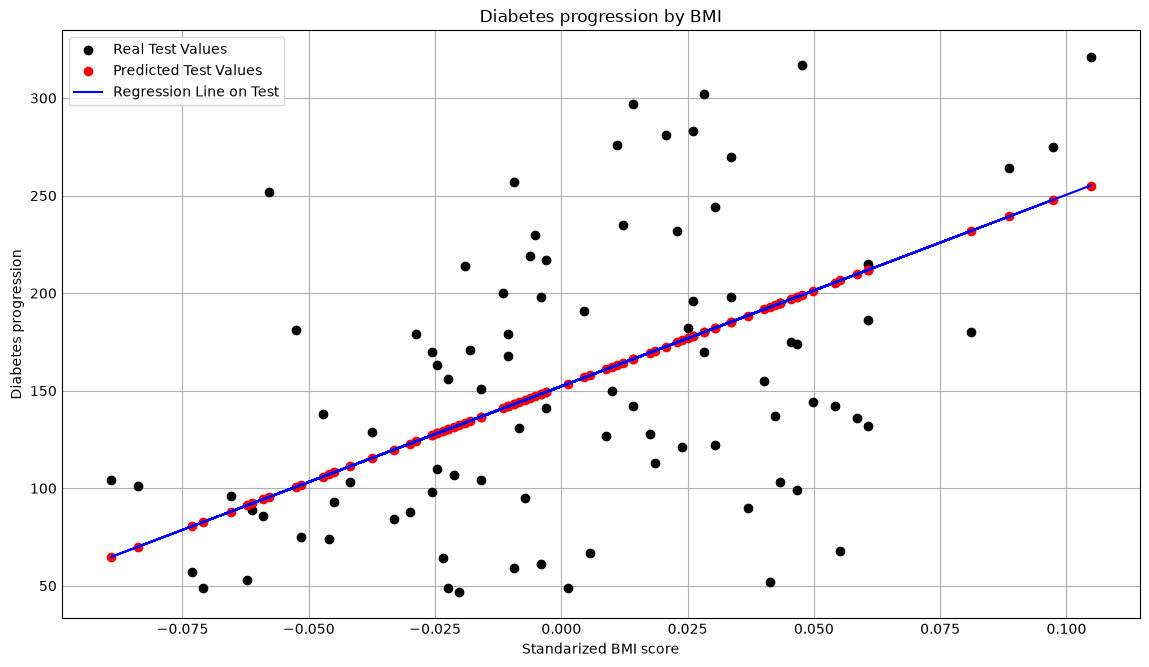

In [169]:
fig, ax = plt.subplots(figsize = (11,6))

_ = plt.scatter(simple_X_test, y_test, 
                color = 'black',
                label = "Real Test Values")

_ = plt.scatter(simple_X_test, simple_y_pred,
                color = 'red',
                label = 'Predicted Test Values')

_ = plt.plot(simple_X_test, simple_y_pred,
             color = 'blue',
             label = 'Regression Line on Test')

_ = plt.legend()

title = "Diabetes progression by BMI"
plt.title(title)

_ = ax.set_xlabel("Standarized BMI score")
_ = ax.set_ylabel("Diabetes progression")

Comment from sklearn original tutorial: OLS on this single-feature subset learns a linear function that minimizes the mean squared error on the training data. We can see how well (or poorly) it generalizes by looking at the R^2 score and mean squared error on the test set. In higher dimensions, pure OLS often overfits, especially if the data is noisy. Regularization techniques (like Ridge or Lasso) can help reduce that.

#### metrics

Let's calculate:
* Mean Square Error (MSE) = average squared difference between the estimated values and true data https://en.wikipedia.org/wiki/Mean_squared_error
* coefficient of determination (R^2) = proportion of the variation in the dependent variable that is predictable from the independent variable(s) https://en.wikipedia.org/wiki/Coefficient_of_determination

In [122]:
model.coef_ #only one, because this is linear

array([981.65543614])

In [123]:
print(f"Coefficient: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Coefficient: 981.66
Intercept: 152.29


In [124]:
from sklearn.metrics import mean_squared_error, r2_score

In [125]:
mse = mean_squared_error(y_test, simple_y_pred)
r2 = r2_score(y_train, model.predict(simple_X_train)) #goodness of fit

In [126]:
print(f"Mean Squared Error (on test data): {mse:.2f}")
print(f"Coefficient of Determination (on train data): {r2:.2f}")

Mean Squared Error (on test data): 4150.68
Coefficient of Determination (on train data): 0.38


# Multiple Linear Regression

y = X * beta + eps

The goal is to calculate the coefficient vetor beta of the least-squares hyperplane

beta^ = (X_T X)^(-1) X_T y
* (X_T X)^(-1) - inverse of the matrix created by X_T and X matrix multiplication

## Manual Implementation

Implementation of ordinary least-squared (OLS) multiple linear regression

### older version adapted from algorithmic perspective on ML book by Stephen Marsland 

what is design matrix? https://en.wikipedia.org/wiki/Design_matrix

In [132]:
def append_intercept(X: pd.DataFrame) -> pd.DataFrame:
    """
    Append a column of ones to the beggining of the dataset.

    Parameters
    ----------
    X: pd.DataFrame
       Observed features data

    Returns
    _______

    pd.DataFrame
       Design matrix
    """

    intercept = np.ones((len(X), 1))
    return np.hstack([intercept, X]) #horizontally, column-wise

In [133]:
def estimate_coefficients(X: pd.DataFrame, y: np.ndarray) -> np.ndarray:
    """
    Returns the estimated beta hat vector.

    Parameters
    __________
    X: pd.DataFrame
       Observed features data
    y: np.ndarray
       Target vector

    Returns
    _______
    np.ndarray
       Estimated coefficients vector
    """
    X = append_intercept(X)
    return np.linalg.inv(X.T @ X) @ (X.T @ y)

In [134]:
def calculate_predictions(X: pd.DataFrame, beta_hat: np.ndarray) -> np.ndarray:
    """
    Returns the predicted values for a test set of observations (X) using a vector of the estimated coefficients.

    Parameters
    __________
    X: pd.DatFrame
       Test features data
    beta_hat: np.ndarray
       Estimated coefficients vector
    
    Returns
    _______
    np.ndarray
       Estimated coefficients
    """
    X = append_intercept(X)
    return X @ beta_hat

#### model application (no actual inicialization or socalled model creation)

In [139]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 0,
                                                    test_size = 0.2)
beta_hat = estimate_coefficients(X_train, y_train)
y_pred_manual_old = calculate_predictions(X_test, beta_hat)

### newer version, which better confronts with standard implementations in ML models

In [137]:
class ManualLinearRegression:
    """
    Manual implementation of an ordinaly least-squares (OLS) Linear Regression model.
    """

    def __init__(self) -> None:
        """
        Initializes a new instance of the ManualLinearRegression model.
        """
        self.beta_hat = None

    def append_intercept(self, X: pd.DataFrame) -> pd.DataFrame:
        """
        Append a column of ones to the beggining of the dataset.

        Parameters
        ----------
        X: pd.DataFrame
           Observed features data

        Returns
        _______

        pd.DataFrame
           Design matrix
        """

        intercept = np.ones((len(X), 1))
        return np.hstack([intercept, X]) #horizontally, column-wise

    def estimate_coefficients(self, X: pd.DataFrame, y: np.ndarray) -> np.ndarray:
        """
        Returns the estimated beta hat vector.

        Parameters
        __________
        X: pd.DataFrame
           Observed features data
        y: np.ndarray
           Target vector

        Returns
        _______
        np.ndarray
           Estimated coefficients vector
        """
        X = append_intercept(X)
        return np.linalg.inv(X.T @ X) @ (X.T @ y)

    
    def fit(self, X: pd.DataFrame, y: np.ndarray) -> None:
        """
        Calculate the estimated coefficients vector (beta hat).

        Parameters
        __________
        X: pd.DataFrame
           Observed features data
        
        y: np.ndarray
           Target vector
        """
        self.beta_hat = self.estimate_coefficients(X, y)

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """
        Returns the predicted values for a test set of observations (X) using a vector of the estimated coefficients.

        Parameters
        __________
        X: pd.DatFrame
           Test features data
        
        Returns
        _______
        np.ndarray
           Estimated coefficients
        """
        if self.beta_hat is not None: #ensure fitting not just initializing
            X = self.append_intercept(X)
            return X @ self.beta_hat

        raise RuntimeError("Please fit the model before calling the predict().")


#### model creation & application

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 0,
                                                    test_size = 0.2)
manual_model = ManualLinearRegression() #initiate OLS LR model
manual_model.fit(X_train, y_train) #estimate beta hat on training data
y_pred_manual = manual_model.predict(X_test) #calculate predictions on test data

#### model evaluation (also manual)

Residual Sum of Squares (RSS)
https://en.wikipedia.org/wiki/Residual_sum_of_squares

In [141]:
ss_residual = np.sum((y_train - manual_model.predict(X_train))**2)
ss_residual

np.float64(965367.0673737369)

Total Sum of Squares (TSS)
https://en.wikipedia.org/wiki/Total_sum_of_squares

In [144]:
ss_total = np.sum((y_train - y_train.mean())**2)
ss_total

np.float64(2164136.266288952)

Coefficient of determination R^2 = 1 - RSS/TSS

In [145]:
r2_score_manual = 1 - ( ss_residual/ss_total )
r2_score_manual

np.float64(0.5539250081377072)

Mean Squared Error (MSE)

In [149]:
mse_manual = np.mean((y_train - manual_model.predict(X_train))**2)
mse_manual

np.float64(2734.750899075742)

and compare with sklearn built-in functions

In [147]:
r2_score(y_true = y_train, 
         y_pred = manual_model.predict(X_train)) == r2_score_manual

np.True_

In [150]:
mean_squared_error(y_train, manual_model.predict(X_train)) == mse_manual

np.True_

## Using sklearn

### model creation & application

The intercept is added to the model by default. It can be turned off by setting a parameter fit_intercept to False.

In [151]:
multiple_model = LinearRegression()
_ = multiple_model.fit(X_train, y_train)
y_pred_all = multiple_model.predict(X_test)

### model evaluation

In [157]:
multiple_model.coef_ # a lot of beta_n, teh amount of features i have (not only bmi as in simple)

array([ -35.55025079, -243.16508959,  562.76234744,  305.46348218,
       -662.70290089,  324.20738537,   24.74879489,  170.3249615 ,
        731.63743545,   43.0309307 ])

In [162]:
print("Model coefficients:")
for i, coef in enumerate(multiple_model.coef_):
    print(f"beta_{i}: {coef:.2f}")

Model coefficients:
beta_0: -35.55
beta_1: -243.17
beta_2: 562.76
beta_3: 305.46
beta_4: -662.70
beta_5: 324.21
beta_6: 24.75
beta_7: 170.32
beta_8: 731.64
beta_9: 43.03


In [158]:
print(f"Intercept: {model.intercept_:.2f}")

Intercept: 152.29


#### on training data

OSL LR is literally optimized on the training data, so metrics on train tell how well the fitted linear model explains the data it was fitted to. Good for under-/over-fitting diagnosis

How well the model fits training data?

In [152]:
mse_all = mean_squared_error(y_train, multiple_model.predict(X_train))
mse_all

2734.7508990757424

Variance explained in training data

In [154]:
r2_score_all = r2_score(y_true = y_train, y_pred = multiple_model.predict(X_train))
r2_score_all

0.5539250081377072

#### on test data

Estimate of out-of-sample/ predictive performance

Generalization error

In [164]:
mse_all_test = mean_squared_error(y_test, y_pred_all)
mse_all_test

3424.259334298692

Variance explained on the unseen data

In [165]:
r2_score_all_test = r2_score(y_true = y_test, y_pred = y_pred_all)
r2_score_all_test

0.3322332173106184